<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/MainQuest/Quest04/AgenticAI/A2A_LangGraph_AiAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Track A — LangGraph Agentic AI 실습

**주제**: LangGraph로 데이터 분석 에이전트 + 리서치 리포트 에이전트 만들기

**학습 목표**
- State / Node / Edge로 워크플로우 설계
- 조건부 분기 + 루프 패턴
- 다국어(영/일/중) 검색 결과 → 한국어 리포트 자동 번역 + 자기검토 루프
- PDF 리포트 생성
- Track B(AutoGen)로 넘길 초안 저장

**환경**: Antigravity IDE + Colab Extension (Colab 웹 호환)

## 목차
- [0] 환경 설정
- [1] LangGraph 코어 개념 (State/Node/Edge)
- [2] 단일 에이전트 + PythonAstREPLTool (Titanic 분석)
- [3] 번역 + 자기검토 유틸리티
- [4] 리서치 리포트 에이전트 (검색 → 번역 → 검토 → PDF)
- [5] Track B로 초안 넘기기
- [6] 정리

## 0. 환경 설정

In [3]:
import subprocess, sys
def pip_install(*packages):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *packages], check=True)

pip_install(
    "langchain",
    "langgraph",
    "langchain-openai",
    "langchain-community",
    "langchain-experimental",
    "tavily-python",
    "fpdf2",
    "pdfplumber",
    "koreanize-matplotlib",
    "pydantic>=2",
)
print("설치 완료")

설치 완료


In [4]:
import os, getpass
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")
if not os.environ.get("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY_API_KEY: ")
print("키 설정 완료")

OPENAI_API_KEY: ··········
TAVILY_API_KEY: ··········
키 설정 완료


In [5]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

WORKDIR = Path.cwd() / "workspace"
WORKDIR.mkdir(exist_ok=True)
(WORKDIR / "fonts").mkdir(exist_ok=True)
(WORKDIR / "data").mkdir(exist_ok=True)
(WORKDIR / "reports").mkdir(exist_ok=True)
print("WORKDIR:", WORKDIR.resolve())

WORKDIR: /content/workspace


In [6]:
import pandas as pd
import requests
import re, io, base64
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

from typing import Annotated, Literal, List
from typing_extensions import TypedDict
from enum import Enum

from langchain_core.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode

from pydantic import BaseModel, Field
from fpdf import FPDF
import pdfplumber
print("임포트 완료")

임포트 완료


In [7]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
llm.invoke("한 문장으로 자기소개").content

'안녕하세요, 저는 다양한 주제에 대해 정보를 제공하고 대화를 나누는 AI입니다.'

## 1. LangGraph 코어 개념

**State** = 열차 위치 + 승객 정보 (공유 메모리)
**Node** = 각 역에서 하는 작업 (함수)
**Edge** = 역과 역을 잇는 노선 (분기/루프 가능)

In [8]:
class HelloState(TypedDict):
    name: str
    greeting: str

def make_greeting(state: HelloState) -> dict:
    return {"greeting": f"안녕하세요, {state['name']}님!"}

g = StateGraph(HelloState)
g.add_node("greet", make_greeting)
g.add_edge(START, "greet")
g.add_edge("greet", END)
app = g.compile()

app.invoke({"name": "모두의연구소"})

{'name': '모두의연구소', 'greeting': '안녕하세요, 모두의연구소님!'}

## 2. 단일 에이전트 + PythonAstREPLTool (Titanic 분석)

In [9]:
csv_path = WORKDIR / "data" / "titanic.csv"
if not csv_path.exists():
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    csv_path.write_bytes(requests.get(url, timeout=30).content)
    print("다운로드 완료")

df = pd.read_csv(csv_path)
print("shape:", df.shape)
df.head(3)

다운로드 완료
shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [10]:
def create_title_summary(df: pd.DataFrame):
    df_sampled = df.sample(n=min(3000, len(df)), random_state=42)
    prompt = PromptTemplate.from_template(
        "당신은 데이터셋 요약 전문가입니다. 반드시 한국어로 답하세요.\n\n"
        "데이터셋:\n{df}\n\n"
        "아래 형식으로만 답하세요.\n"
        "제목: <한 줄>\n"
        "요약: <3~5문장>\n"
    )
    result = (prompt | llm).invoke({"df": df_sampled.to_string()})
    content = result.content.strip()
    title, summary = "Untitled", "No Summary"
    try:
        m_title = re.search(r"제목\s*[:：]\s*(.+)", content)
        m_summary = re.search(r"요약\s*[:：]\s*(.+)", content, re.S)
        if m_title: title = m_title.group(1).strip()
        if m_summary: summary = m_summary.group(1).strip()
    except Exception:
        pass
    return title, summary

title, summary = create_title_summary(df)
print("제목:", title)
print("요약:", summary)

제목: 타이타닉 승객 데이터셋 요약
요약: 이 데이터셋은 타이타닉 호의 승객 정보를 포함하고 있으며, 총 891명의 승객에 대한 다양한 특성이 기록되어 있습니다. 각 승객의 생존 여부(Survived), 객실 등급(Pclass), 이름(Name), 성별(Sex), 나이(Age), 형제/자매 수(SibSp), 부모/자녀 수(Parch), 티켓 번호(Ticket), 요금(Fare), 객실 번호(Cabin), 그리고 탑승 항구(Embarked) 등의 정보가 포함되어 있습니다. 생존 여부는 1(생존)과 0(사망)으로 표시되어 있으며, 데이터에는 결측치도 존재합니다. 이 데이터셋은 생존율 분석 및 다양한 통계적 연구에 활용될 수 있습니다.


In [11]:
tool = PythonAstREPLTool(
    name="python_repl_ast",
    description=(
        "A Python shell. Use this to execute python commands. "
        "Input should be a valid python command."
    ),
    locals={"df": df},
)
llm_with_tools = llm.bind_tools([tool])
print("도구 바인딩 완료")

도구 바인딩 완료


In [12]:
class DataState(TypedDict):
    messages: Annotated[list, add_messages]
    code: str
    code_result: str

class HistoryChecker(BaseModel):
    yes_no: Literal["yes", "no"] = Field(..., description="답변 가능하면 'yes', 불가하면 'no'")

history_checker = llm.with_structured_output(HistoryChecker)

def history_check(state: DataState) -> str:
    if len(state["messages"]) <= 1:
        return "no"
    prompt = PromptTemplate.from_template(
        "이전 대화를 보고 현재 질문에 답할 수 있는지 yes/no로만 답하세요.\n"
        "대화: {history}\n질문: {query}"
    )
    result = (prompt | history_checker).invoke({
        "history": state["messages"][:-1],
        "query": state["messages"][-1].content,
    })
    return result.yes_no

In [13]:
def history_node(state: DataState) -> dict:
    return {}

def select(state: DataState) -> dict:
    prompt = PromptTemplate.from_template(
        "당신은 데이터 분석가입니다. df라는 pandas DataFrame이 준비되어 있습니다.\n"
        "반드시 한국어로 사고하고, 도구 호출 시 코드만 전달하세요.\n\n"
        "df.head():\n{df}\n\n"
        "제목: {title}\n요약: {summary}\n\n"
        "질문: {query}\n\n"
        "'python_repl_ast' 도구로 코드를 생성하세요.\n"
        "시각화 시 koreanize_matplotlib을 import하세요.\n"
    )
    result = (prompt | llm_with_tools).invoke({
        "df": df.head().to_string(),
        "title": title,
        "summary": summary,
        "query": state["messages"][-1].content,
    })
    if getattr(result, "tool_calls", None):
        return {"code": result.tool_calls[0]["args"]["query"]}
    return {"code": ""}

def code_executor(state: DataState) -> dict:
    code = state.get("code", "").strip()
    if not code:
        return {"code_result": ""}
    if ("plt" in code) or ("sns" in code):
        save_fig = (
            "\nimport io, base64\n"
            "buf = io.BytesIO()\n"
            "plt.savefig(buf, format='png', bbox_inches='tight')\n"
            "buf.seek(0)\n"
            "_img_b64 = base64.b64encode(buf.read()).decode('utf-8')\n"
            "print(_img_b64)\n"
        )
        exec_code = code + save_fig
    else:
        exec_code = code
    try:
        result = tool.invoke(exec_code)
        return {"code_result": str(result)}
    except Exception as e:
        return {"code_result": f"[코드 실행 오류] {type(e).__name__}: {e}"}

def code_response(state: DataState) -> dict:
    sys_prompt = (
        "당신은 데이터 분석 결과를 설명하는 어시스턴트입니다. 반드시 한국어로 답하세요.\n"
        "- 코드는 설명하지 마세요.\n"
        "- 출력된 숫자 중심으로 설명하세요.\n"
        "- 인사이트를 3개 이상 포함하세요.\n"
        "- base64 문자열이면 '시각화가 생성되었습니다'라고 언급하세요.\n\n"
        "[코드]\n{code}\n\n[결과]\n{code_result}"
    )
    prompt = ChatPromptTemplate.from_messages([("system", sys_prompt), ("human", "{query}")])
    result = (prompt | llm).invoke({
        "code": state["code"],
        "code_result": state["code_result"],
        "query": state["messages"][-1].content,
    })
    return {"messages": result}

def response(state: DataState) -> dict:
    prompt = PromptTemplate.from_template(
        "이전 대화를 참고해 질문에 한국어로 답하세요.\n"
        "대화: {history}\n질문: {query}"
    )
    result = (prompt | llm).invoke({
        "history": state["messages"][:-1],
        "query": state["messages"][-1],
    })
    return {"messages": result}

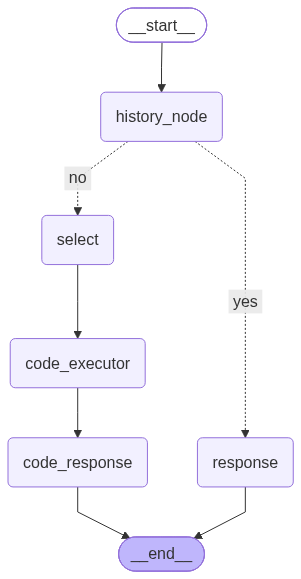

In [14]:
gb = StateGraph(DataState)
gb.add_node("history_node", history_node)
gb.add_node("select", select)
gb.add_node("code_executor", code_executor)
gb.add_node("code_response", code_response)
gb.add_node("response", response)

gb.add_edge(START, "history_node")
gb.add_conditional_edges("history_node", history_check, {"yes": "response", "no": "select"})
gb.add_edge("select", "code_executor")
gb.add_edge("code_executor", "code_response")
gb.add_edge("code_response", END)
gb.add_edge("response", END)

memory = InMemorySaver()
data_graph = gb.compile(checkpointer=memory)
data_graph

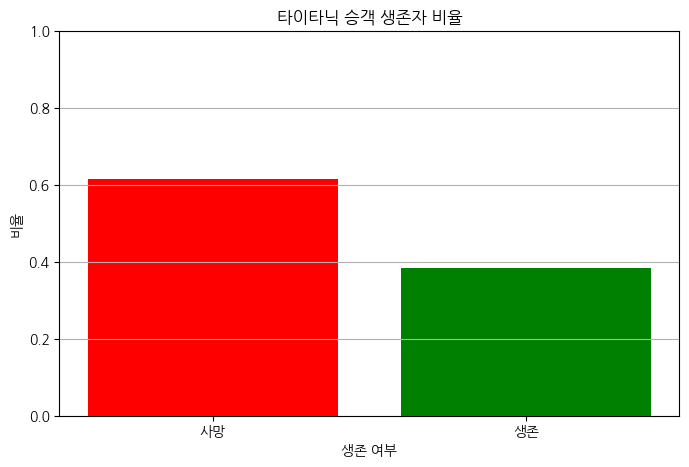

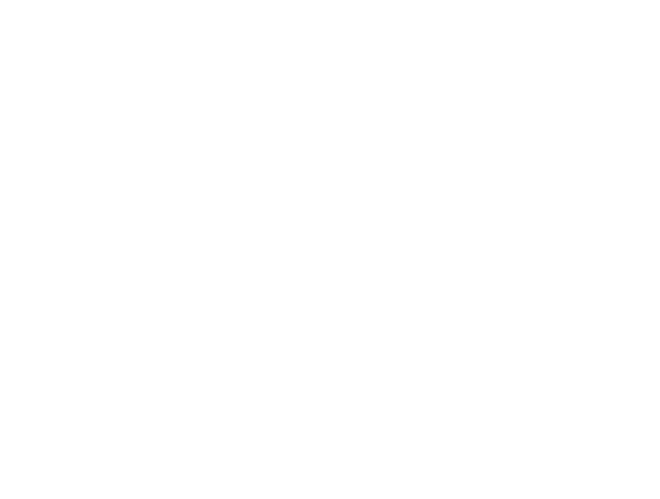

================================== Ai Message ==================================

시각화가 생성되었습니다.

1. 생존자 비율: 타이타닉 승객 중 생존한 비율은 약 38%로 나타났습니다. 이는 전체 승객의 약 62%가 사망했음을 의미합니다.

2. 생존자와 사망자의 비율: 생존자는 사망자에 비해 상대적으로 적은 수치로, 이는 타이타닉 사고의 치명성을 잘 보여줍니다. 생존자 비율이 낮다는 것은 구조 작업이 어려웠던 상황을 반영합니다.

3. 생존자 비율의 개선 가능성: 생존자 비율이 낮은 점은 향후 유사한 사고에서 구조 및 구호 작업의 중요성을 강조합니다. 이를 통해 생존자 비율을 높이기 위한 다양한 안전 대책과 교육이 필요하다는 인사이트를 제공합니다.


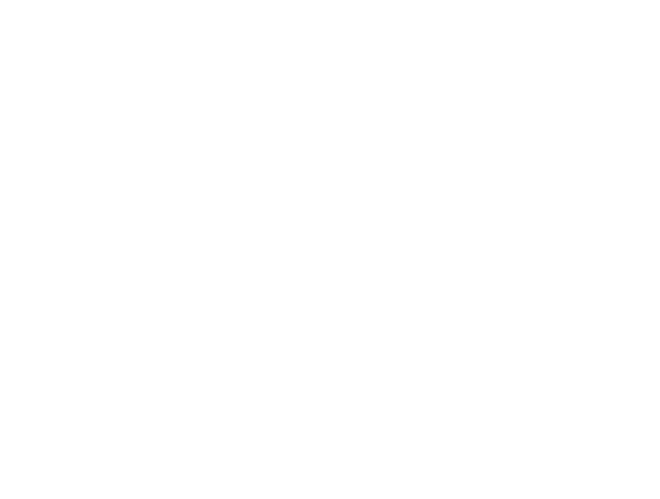

<Figure size 640x480 with 0 Axes>

In [15]:
from IPython.display import display, Image

def stream_data_graph(query: str, thread_id: str = "titanic-1"):
    config = RunnableConfig(recursion_limit=10, configurable={"thread_id": thread_id})
    for step in data_graph.stream({"messages": ("user", query)}, config=config, stream_mode="values"):
        msgs = step.get("messages", [])
        if not msgs:
            continue
        last = msgs[-1]
        if isinstance(last, AIMessage):
            last.pretty_print()
        cr = step.get("code_result", "")
        if cr and len(cr) > 500 and re.fullmatch(r"[A-Za-z0-9+/=\s]+", cr or ""):
            try:
                display(Image(data=base64.b64decode(cr.strip())))
            except Exception:
                pass

stream_data_graph("생존자 비율을 시각화하고 인사이트 3개를 알려줘")

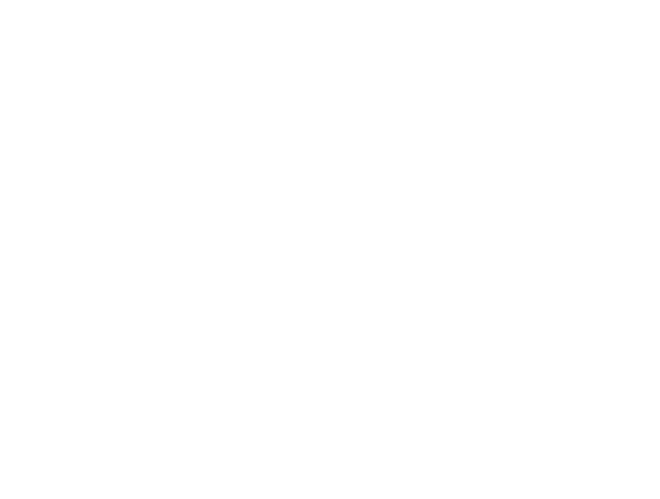

================================== Ai Message ==================================

네, 아까 생존자 비율을 시각화하고 인사이트 3개를 알려달라고 하셨습니다. 그에 대한 답변으로 생존자 비율, 생존자와 사망자의 비율, 생존자 비율의 개선 가능성에 대한 인사이트를 제공했습니다. 추가로 궁금한 점이 있으신가요?


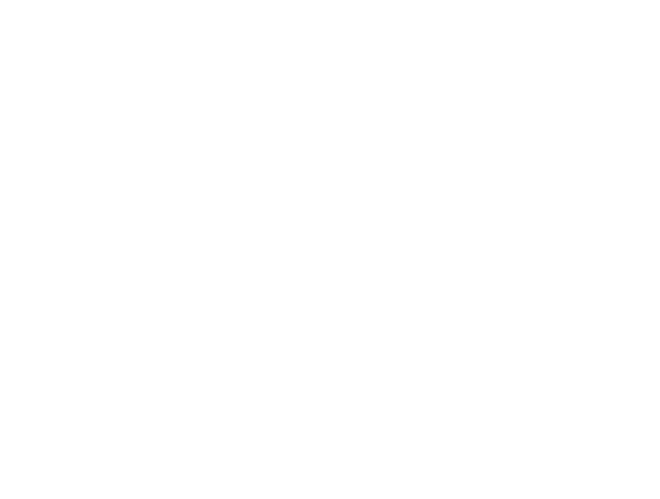

In [16]:
stream_data_graph("아까 내가 뭘 물어봤는지 기억해?")

## 3. 번역 + 자기검토 유틸리티

In [17]:
class SourceLang(str, Enum):
    EN = "en"
    JA = "ja"
    ZH = "zh"
    KO = "ko"
    MIX = "mix"

def detect_lang(text: str) -> SourceLang:
    if not text:
        return SourceLang.EN
    ja = sum(1 for c in text if '\u3040' <= c <= '\u30ff')
    zh = sum(1 for c in text if '\u4e00' <= c <= '\u9fff')
    ko = sum(1 for c in text if '\uac00' <= c <= '\ud7a3')
    en = sum(1 for c in text if c.isascii() and c.isalpha())
    counts = {"ja": ja, "zh": zh, "ko": ko, "en": en}
    top = max(counts, key=counts.get)
    if counts[top] == 0:
        return SourceLang.EN
    if top != "ko" and counts["ko"] > 20:
        return SourceLang.MIX
    return SourceLang(top)

LANG_RULES = {
    "en": "영어 고유명사는 '한국어(영어)' 형식. 예: 현대자동차(Hyundai Motor Company)",
    "ja": "일본어 고유명사는 '한국어(일본어)' 형식. 예: 도요타(トヨタ)",
    "zh": "중국어 고유명사는 '한국어(중국어)' 형식. 예: 알리바바(阿里巴巴)",
    "mix": "각 언어별 고유명사 규칙을 모두 적용하세요.",
    "ko": "이미 한국어. 맞춤법/띄어쓰기만 다듬으세요.",
}

TRANSLATE_PROMPT = PromptTemplate.from_template(
    "당신은 다국어 비즈니스 문서 번역 전문가입니다.\n"
    "[목표 언어] 한국어\n[원문 언어] {source_lang}\n[언어별 규칙] {lang_rule}\n\n"
    "[번역 규칙]\n"
    "1. 원문의 모든 정보를 빠짐없이 번역\n"
    "2. 숫자/날짜/통화는 원문 유지 + 한국식 병기\n"
    "3. 고유명사는 첫 등장 시 '한국어(원어)' 병기\n"
    "4. 애매한 표현은 의역하되 각주로 원문 병기\n"
    "5. 문장은 짧게, 능동태 위주로\n\n"
    "text:\n{text}\n"
)

print(detect_lang("Hyundai Motor announced Q4 results"))
print(detect_lang("トヨタ自動車は新車を発表しました"))
print(detect_lang("阿里巴巴发布了新的财报"))

SourceLang.EN
SourceLang.JA
SourceLang.ZH


In [18]:
class TranslationReview(BaseModel):
    score: int = Field(..., ge=0, le=10)
    completeness: int = Field(..., ge=0, le=3)
    accuracy: int = Field(..., ge=0, le=3)
    naturalness: int = Field(..., ge=0, le=2)
    consistency: int = Field(..., ge=0, le=2)
    issues: List[str] = Field(default_factory=list)
    needs_retranslation: bool = Field(...)
    reason: str = Field(...)

reviewer = llm.with_structured_output(TranslationReview)

REVIEW_PROMPT = PromptTemplate.from_template(
    "당신은 한국어 번역 품질 검토자입니다.\n"
    "[채점] 완전성(3)/정확성(3)/자연스러움(2)/일관성(2) 총 10점\n\n"
    "[원문]\n{original}\n\n[번역]\n{translated}\n"
)

def translate_text(text: str) -> str:
    lang = detect_lang(text)
    return (TRANSLATE_PROMPT | llm).invoke({
        "source_lang": lang.value,
        "lang_rule": LANG_RULES[lang.value],
        "text": text,
    }).content

def review_translation(original: str, translated: str) -> TranslationReview:
    return (REVIEW_PROMPT | reviewer).invoke({
        "original": original,
        "translated": translated,
    })

print("번역 유틸 준비 완료")

번역 유틸 준비 완료


## 4. 리서치 리포트 에이전트 (검색 → 번역 → 검토 → PDF)

**노드 흐름**
- `select` → `tools` → `translate` → `review` → (`retranslate` ↺ `review`) → `report` → `response`

In [19]:
from langchain_core.tools import tool

search_tool = TavilySearchResults(max_results=5, name="tavily_search")

FONT_PATH = WORKDIR / "fonts" / "NotoSansKR.ttf"
if not FONT_PATH.exists():
    font_url = "https://github.com/google/fonts/raw/main/ofl/notosanskr/NotoSKR%5Bwght%5D.ttf"
    FONT_PATH.write_bytes(requests.get(font_url, timeout=60).content)

@tool
def save_pdf(content: str, filename: str = "report.pdf") -> str:
    """한국어 텍스트를 PDF로 저장합니다."""
    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_font("NotoSans", "", str(FONT_PATH), uni=True)
    pdf.set_font("NotoSans", size=12)
    for line in content.split("\n"):
        pdf.multi_cell(0, 8, line)
    out_path = WORKDIR / "reports" / filename
    pdf.output(str(out_path))
    return f"{out_path} 저장 완료"

tools = [search_tool, save_pdf]
llm_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)
print("리서치 도구 준비 완료")

/tmp/ipykernel_1403/3438460975.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=5, name="tavily_search")


리서치 도구 준비 완료


In [20]:
class ReportState(TypedDict):
    messages: Annotated[list, add_messages]
    query: str
    raw_content: str
    source_lang: str
    translated: str
    review_score: int
    review_issues: List[str]
    retry_count: int
    final_report: str

def history_node_r(state: ReportState) -> dict:
    return {}

def select_r(state: ReportState) -> dict:
    prompt = PromptTemplate.from_template(
        "당신은 리서치 어시스턴트입니다.\n"
        "tavily_search로 검색하고, 필요하면 save_pdf를 호출하세요.\n"
        "질문: {query}"
    )
    result = (prompt | llm_tools).invoke({"query": state["messages"][-1].content})
    return {"messages": result}

def tool_collector(state: ReportState) -> dict:
    texts = []
    for m in state["messages"]:
        content = getattr(m, "content", "")
        if content and isinstance(content, str):
            texts.append(content)
    raw = "\n\n".join(texts[-5:])
    return {"raw_content": raw}

def translate_node(state: ReportState) -> dict:
    lang = detect_lang(state["raw_content"])
    translated = (TRANSLATE_PROMPT | llm).invoke({
        "source_lang": lang.value,
        "lang_rule": LANG_RULES[lang.value],
        "text": state["raw_content"],
    }).content
    return {"source_lang": lang.value, "translated": translated}

def review_node(state: ReportState) -> dict:
    review = (REVIEW_PROMPT | reviewer).invoke({
        "original": state["raw_content"],
        "translated": state["translated"],
    })
    return {"review_score": review.score, "review_issues": review.issues}

def should_retranslate(state: ReportState) -> str:
    if state["review_score"] >= 8:
        return "report"
    if state["retry_count"] >= 2:
        return "report"
    return "retranslate"

def retranslate_node(state: ReportState) -> dict:
    issues_text = "\n".join(f"- {i}" for i in state["review_issues"]) or "- 없음"
    prompt = PromptTemplate.from_template(
        "아래 번역문에 다음 문제가 있습니다:\n{issues}\n\n"
        "재번역하세요.\n[원문]\n{original}\n\n[이전]\n{previous}"
    )
    result = (prompt | llm).invoke({
        "issues": issues_text,
        "original": state["raw_content"],
        "previous": state["translated"],
    })
    return {"translated": result.content, "retry_count": state["retry_count"] + 1}

In [22]:
def report_node(state: ReportState) -> dict:
    prompt = PromptTemplate.from_template(
        "다음 번역문을 한국어 리포트로 정리하세요.\n"
        "# 제목 / ## 1. 개요 / ## 2. 주요 내용 / ## 3. 인사이트\n"
        "마지막에 '## 출처' 섹션.\n\n"
        "번역문:\n{translated}"
    )
    result = (prompt | llm).invoke({"translated": state["translated"]})
    return {"final_report": result.content}

def response_r(state: ReportState) -> dict:
    return {"messages": AIMessage(content=state["final_report"])}